<a href="https://colab.research.google.com/github/Dyuko/DataScience/blob/main/word_embeddings.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install numpy==1.21.6 gensim==4.2.0 scikit-learn==1.0.2 matplotlib==3.5.2

ERROR: Ignored the following versions that require a different python version: 1.21.2 Requires-Python >=3.7,<3.11; 1.21.3 Requires-Python >=3.7,<3.11; 1.21.4 Requires-Python >=3.7,<3.11; 1.21.5 Requires-Python >=3.7,<3.11; 1.21.6 Requires-Python >=3.7,<3.11
ERROR: Could not find a version that satisfies the requirement numpy==1.21.6 (from versions: 1.3.0, 1.4.1, 1.5.0, 1.5.1, 1.6.0, 1.6.1, 1.6.2, 1.7.0, 1.7.1, 1.7.2, 1.8.0, 1.8.1, 1.8.2, 1.9.0, 1.9.1, 1.9.2, 1.9.3, 1.10.0.post2, 1.10.1, 1.10.2, 1.10.4, 1.11.0, 1.11.1, 1.11.2, 1.11.3, 1.12.0, 1.12.1, 1.13.0, 1.13.1, 1.13.3, 1.14.0, 1.14.1, 1.14.2, 1.14.3, 1.14.4, 1.14.5, 1.14.6, 1.15.0, 1.15.1, 1.15.2, 1.15.3, 1.15.4, 1.16.0, 1.16.1, 1.16.2, 1.16.3, 1.16.4, 1.16.5, 1.16.6, 1.17.0, 1.17.1, 1.17.2, 1.17.3, 1.17.4, 1.17.5, 1.18.0, 1.18.1, 1.18.2, 1.18.3, 1.18.4, 1.18.5, 1.19.0, 1.19.1, 1.19.2, 1.19.3, 1.19.4, 1.19.5, 1.20.0, 1.20.1, 1.20.2, 1.20.3, 1.21.0, 1.21.1, 1.22.0, 1.22.1, 1.22.2, 1.22.3, 1.22.4, 1.23.0, 1.23.1, 1.23.2, 1.23.3, 1.23

In [2]:
import gensim.downloader as api
from gensim.models import KeyedVectors
from gensim.scripts.glove2word2vec import glove2word2vec
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np
import os
import requests
from tqdm import tqdm
import zipfile

In [3]:
# Función para descargar archivos con barra de progreso
def download_file(url, filename):
    response = requests.get(url, stream=True)
    total_size = int(response.headers.get('content-length', 0))

    with open(filename, 'wb') as f, tqdm(
        desc=filename,
        total=total_size,
        unit='iB',
        unit_scale=True,
        unit_divisor=1024,
    ) as bar:
        for data in response.iter_content(chunk_size=1024):
            size = f.write(data)
            bar.update(size)

In [4]:
# Cargar listas de palabras
def load_words(filename):
    with open(filename, 'r') as f:
        return [line.strip() for line in f.readlines() if line.strip()]

In [5]:
#Leer de google driver
from google.colab import drive
drive.mount('/content/drive')

# Carpeta datos
data_folder = '/content/drive/MyDrive/datos/'

# Archivos
food_words_path = os.path.join(data_folder, 'food_words.txt')
sports_words_path = os.path.join(data_folder, 'sports_words.txt')
weather_words_path = os.path.join(data_folder, 'weather_words.txt')

# Cargar archivos
food_words = load_words(food_words_path)
sports_words = load_words(sports_words_path)
weather_words = load_words(weather_words_path)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
food_words[0:3]

['acorn squash', 'alfalfa sprouts', 'almond']

In [7]:
sports_words[0:3]

['aerobics', 'archer', 'archery']

In [8]:
weather_words[0:3]

['accumulation', 'advisory', 'air']

In [9]:
all_words = food_words + sports_words + weather_words
categories = ['food']*len(food_words) + ['sports']*len(sports_words) + ['weather']*len(weather_words)
colors = {'food': 'blue', 'sports': 'red', 'weather': 'green'}

In [10]:
# Función para obtener vectores de palabras
def get_word_vectors(word_list, model):
    vectors = []
    valid_words = []
    for word in word_list:
        try:
            vectors.append(model[word])
            valid_words.append(word)
        except KeyError:
            continue
    return np.array(vectors), valid_words

In [11]:
# Función para visualizar con t-SNE
def visualize_tsne(vectors, words, categories, title, color_map):
    tsne = TSNE(n_components=2, random_state=42)
    vectors_2d = tsne.fit_transform(vectors)

    plt.figure(figsize=(12, 8))
    for i, (x, y) in enumerate(vectors_2d):
        category = categories[i]
        plt.scatter(x, y, c=color_map[category], label=category if i == 0 else "")

    # Crear leyenda única
    handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color, markersize=10)
               for color in color_map.values()]
    plt.legend(handles, color_map.keys(), loc='best')

    plt.title(title)
    plt.xlabel('t-SNE dimension 1')
    plt.ylabel('t-SNE dimension 2')
    plt.grid(alpha=0.3)
    plt.show()

Cargando Word2Vec...


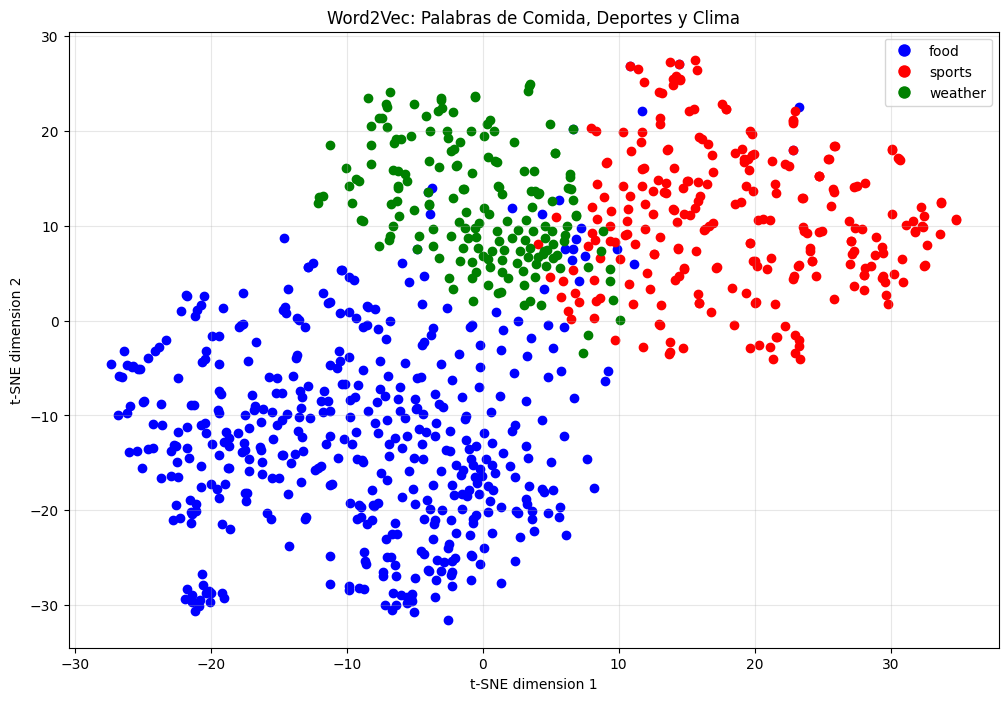

In [12]:
# 1. Word2Vec (Google News)
print("Cargando Word2Vec...")
word2vec_model = api.load('word2vec-google-news-300')

# Obtener vectores y palabras válidas
w2v_vectors, valid_words = get_word_vectors(all_words, word2vec_model)
valid_categories = [cat for word, cat in zip(all_words, categories) if word in valid_words]

# Visualizar
visualize_tsne(w2v_vectors, valid_words, valid_categories,
               'Word2Vec: Palabras de Comida, Deportes y Clima', colors)


Cargando FastText...


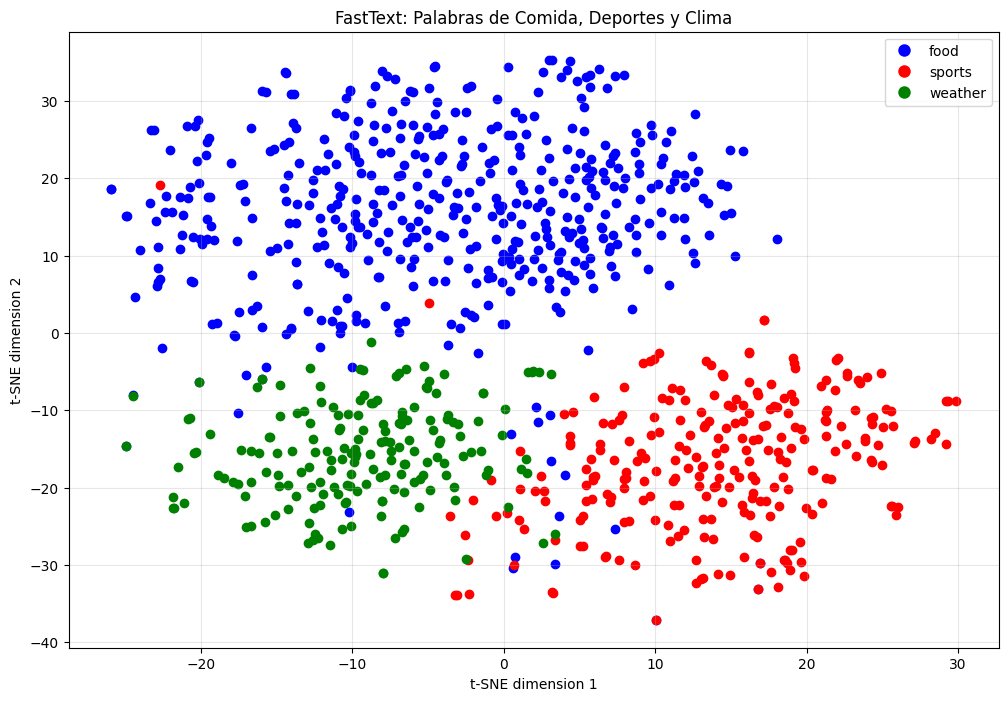

In [13]:
# 2. FastText
print("\nCargando FastText...")
fasttext_model = api.load('fasttext-wiki-news-subwords-300')

# Obtener vectores y palabras válidas
ft_vectors, valid_words = get_word_vectors(all_words, fasttext_model)
valid_categories = [cat for word, cat in zip(all_words, categories) if word in valid_words]

# Visualizar
visualize_tsne(ft_vectors, valid_words, valid_categories,
               'FastText: Palabras de Comida, Deportes y Clima', colors)


Descargando y procesando GloVe...
Descargando https://nlp.stanford.edu/data/glove.6B.zip...


glove.6B.zip: 100%|██████████| 822M/822M [02:39<00:00, 5.42MiB/s]


Extrayendo glove.6B.zip...
Convirtiendo formato GloVe a Word2Vec...


<ipython-input-14-62eba89f8952>:22: DeprecationWarning: Call to deprecated `glove2word2vec` (KeyedVectors.load_word2vec_format(.., binary=False, no_header=True) loads GLoVE text vectors.).
  glove2word2vec(glove_file, word2vec_output_file)


Cargando vectores GloVe...


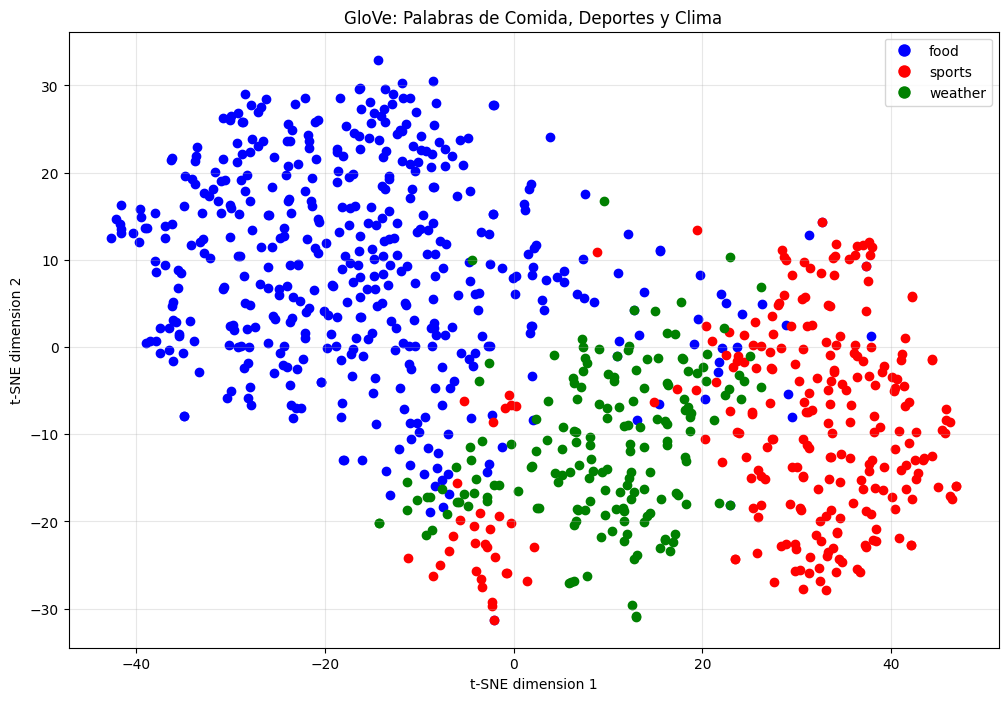

In [14]:
# 3. GloVe - Descarga y procesamiento automático
print("\nDescargando y procesando GloVe...")
glove_url = 'https://nlp.stanford.edu/data/glove.6B.zip'
glove_zip = 'glove.6B.zip'
glove_file = 'glove.6B.300d.txt'
word2vec_output_file = 'glove.6B.300d.word2vec.txt'

# Descargar el archivo GloVe si no existe
if not os.path.exists(glove_zip):
    print(f"Descargando {glove_url}...")
    download_file(glove_url, glove_zip)

# Extraer el archivo si no está extraído
if not os.path.exists(glove_file):
    print(f"Extrayendo {glove_zip}...")
    with zipfile.ZipFile(glove_zip, 'r') as zip_ref:
        zip_ref.extractall()

# Convertir formato GloVe a Word2Vec si no está convertido
if not os.path.exists(word2vec_output_file):
    print("Convirtiendo formato GloVe a Word2Vec...")
    glove2word2vec(glove_file, word2vec_output_file)

# Cargar los vectores convertidos
print("Cargando vectores GloVe...")
glove_model = KeyedVectors.load_word2vec_format(word2vec_output_file, binary=False)

# Obtener vectores y palabras válidas
glove_vectors, valid_words = get_word_vectors(all_words, glove_model)
valid_categories = [cat for word, cat in zip(all_words, categories) if word in valid_words]

# Visualizar
visualize_tsne(glove_vectors, valid_words, valid_categories,
               'GloVe: Palabras de Comida, Deportes y Clima', colors)